<a href="https://colab.research.google.com/github/faith-dev122/BIT4133-NLP-Project/blob/main/Week_8_Extra_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# WEEK 8: Installing Hugging Face Transformers library
!pip install transformers torch --quiet

import transformers
import torch
print("Transformers version:", transformers.__version__)
print("PyTorch version    :", torch.__version__)
print("All libraries ready for Transformer tasks!")

Transformers version: 5.12.0
PyTorch version    : 2.11.0+cpu
All libraries ready for Transformer tasks!


In [7]:
# WEEK 8 EXTRA WORK 1: Five Different Transformer Pipelines
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from transformers import pipeline
import nltk

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("FIVE TRANSFORMER NLP PIPELINES")
print("=" * 65)
print("Demonstrating the breadth of pre-trained Transformer models\n")

# PIPELINE 1: SENTIMENT ANALYSIS
print("1. SENTIMENT ANALYSIS")
print("-" * 45)

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

texts = [
    "I love this NLP course!",
    "The exam was very difficult.",
    "Nairobi is a wonderful city.",
    "This assignment is so confusing and frustrating."
]

for text in texts:
    r = classifier(text)[0]
    flag = "😊" if r['label'] == "POSITIVE" else "😞"
    print(f"   {flag} '{text}'")
    print(f"      → {r['label']} ({r['score']*100:.1f}%)\n")

# PIPELINE 2: NAMED ENTITY RECOGNITION
print("2. NAMED ENTITY RECOGNITION")
print("-" * 45)

ner = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple"
)

ner_sentences = [
    "Barack Obama studied at Harvard University in the United States.",
    "Elon Musk founded Tesla and SpaceX in California.",
    "The University of Nairobi is located in Kenya in East Africa."
]

for sent in ner_sentences:
    entities = ner(sent)
    print(f"   Sentence: '{sent}'")
    for ent in entities:
        print(f"   → '{ent['word']}' [{ent['entity_group']}] "
              f"score: {ent['score']*100:.1f}%")
    print()

# PIPELINE 3: TEXT SUMMARIZATION
# Using extractive approach since pipeline task not available
print("3. TEXT SUMMARIZATION")
print("-" * 45)
print("   Method: Extractive summarization using word frequency\n")

long_text = """
Natural Language Processing is a branch of Artificial Intelligence
that focuses on enabling computers to understand, interpret, and generate
human language. It combines techniques from linguistics, computer science,
and machine learning to process and analyze large amounts of natural
language data. Applications include machine translation, sentiment analysis,
chatbots, speech recognition, text summarization, and spam detection.
Modern NLP systems use deep learning models such as Transformers,
which have achieved human-level performance on many language tasks.
Word embeddings and neural networks form the backbone of these systems.
Transformers use attention mechanisms to understand relationships between words.
"""

stop_words = set(stopwords.words('english'))
sentences  = sent_tokenize(long_text.strip())
words      = [
    w.lower() for w in word_tokenize(long_text)
    if w.isalpha() and w.lower() not in stop_words
]
freq = Counter(words)

scores = {}
for sent in sentences:
    score = sum(
        freq.get(w.lower(), 0)
        for w in word_tokenize(sent) if w.isalpha()
    )
    scores[sent] = score

top_2   = sorted(scores, key=scores.get, reverse=True)[:2]
summary = ' '.join(top_2)

print(f"   Original : {len(long_text.split())} words")
print(f"   Summary  : {len(summary.split())} words")
print(f"   Result   : {summary.strip()}")
print()

# PIPELINE 4: FILL MASK (Word Prediction)
# fill-mask IS available in your version
print("4. FILL-MASK (Masked Word Prediction)")
print("-" * 45)
print("   The model predicts the missing [MASK] word in a sentence")
print("   This demonstrates BERT's Masked Language Modelling ability\n")

fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased"
)

masked_sentences = [
    "Natural Language Processing is a field of [MASK] intelligence.",
    "The student submitted her [MASK] before the deadline.",
    "Nairobi is the [MASK] city of Kenya.",
    "The transformer model uses [MASK] mechanisms to understand text."
]

for masked in masked_sentences:
    results = fill_mask(masked)
    print(f"   Sentence: '{masked}'")
    print(f"   Top 3 predictions for [MASK]:")
    for r in results[:3]:
        print(f"     → '{r['token_str']}'  ({r['score']*100:.1f}%)")
    print()

# PIPELINE 5: ZERO-SHOT CLASSIFICATION
print("5. ZERO-SHOT CLASSIFICATION")
print("-" * 45)
print("   Classify text into categories WITHOUT any training!\n")

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

test_cases = [
    {
        "text"  : "The government announced new infrastructure projects for Nairobi.",
        "labels": ["politics", "technology", "sports", "finance", "education"]
    },
    {
        "text"  : "The student submitted her NLP assignment before the deadline.",
        "labels": ["academics", "sports", "cooking", "business", "travel"]
    },
    {
        "text"  : "Safaricom launched a new M-Pesa feature for small businesses.",
        "labels": ["technology", "finance", "sports", "health", "education"]
    }
]

for case in test_cases:
    result = zero_shot(case["text"], case["labels"])
    print(f"   Text  : '{case['text']}'")
    print(f"   Labels: {case['labels']}")
    print(f"   Results:")
    for label, score in zip(result['labels'], result['scores']):
        bar = '█' * int(score * 20)
        print(f"     {label:<15} {score*100:.1f}%  {bar}")
    print()

print("=" * 65)
print("ALL FIVE PIPELINES COMPLETED SUCCESSFULLY")
print("=" * 65)
print(f"\n{'Pipeline':<5} {'Task':<30} {'Method Used'}")
print("-" * 65)
print(f"  1     {'Sentiment Analysis':<30} DistilBERT classification")
print(f"  2     {'Named Entity Recognition':<30} BERT-large NER model")
print(f"  3     {'Text Summarization':<30} Extractive word frequency")
print(f"  4     {'Fill-Mask / Word Prediction':<30} BERT masked language model")
print(f"  5     {'Zero-Shot Classification':<30} BART-large-MNLI")
print()
print("NOTE ON PIPELINE 3:")
print("  Summarization was removed from the pipeline() API in this")
print("  version of Transformers. Extractive summarization was used")
print("  instead — selecting the highest-scoring sentences based on")
print("  word frequency, a classical NLP technique from Week 1-2.")
print("  This demonstrates how core NLP knowledge allows adaptation")
print("  when library versions change — an important engineering skill.")

FIVE TRANSFORMER NLP PIPELINES
Demonstrating the breadth of pre-trained Transformer models

1. SENTIMENT ANALYSIS
---------------------------------------------


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

   😊 'I love this NLP course!'
      → POSITIVE (100.0%)

   😞 'The exam was very difficult.'
      → NEGATIVE (99.9%)

   😊 'Nairobi is a wonderful city.'
      → POSITIVE (100.0%)

   😞 'This assignment is so confusing and frustrating.'
      → NEGATIVE (100.0%)

2. NAMED ENTITY RECOGNITION
---------------------------------------------


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

   Text  : 'The government announced new infrastructure projects for Nairobi.'
   Labels: ['politics', 'technology', 'sports', 'finance', 'education']
   Results:
     finance         63.7%  ████████████
     politics        15.9%  ███
     technology      15.5%  ███
     sports          2.9%  
     education       2.0%  

   Text  : 'The student submitted her NLP assignment before the deadline.'
   Labels: ['academics', 'sports', 'cooking', 'business', 'travel']
   Results:
     academics       92.4%  ██████████████████
     business        3.9%  
     travel          2.1%  
     cooking         0.8%  
     sports          0.7%  

   Text  : 'Safaricom launched a new M-Pesa feature for small businesses.'
   Labels: ['technology', 'finance', 'sports', 'health', 'education']
   Results:
     technology      84.5%  ████████████████
     finance         12.9%  ██
     health          1.1%  
     sports          0.8%  
     education       0.7%  

ALL FIVE PIPELINES COMPLETED SUCCESSFULLY


In [8]:
# WEEK 8 EXTRA WORK 2: BERT vs GPT-2 Complete Comparison
# Encoder vs Decoder architecture comparison
from transformers import pipeline

print("BERT vs GPT-2 — ENCODER vs DECODER COMPARISON")
print("=" * 65)
print("BERT  = Encoder only → understands text (classification tasks)")
print("GPT-2 = Decoder only → generates text (generation tasks)\n")

# BERT Encoder: Understanding Tasks
print("PART 1: BERT (Encoder) — Understanding Tasks")
print("=" * 65)

bert_classifier = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

sentences = [
    "This NLP course is absolutely brilliant and well structured.",
    "I struggled with the assignment and the deadline was too tight.",
    "The lecture covered transformer models in great detail.",
    "The exam results were disappointing after all that hard work.",
    "Nairobi is a wonderful city full of vibrant culture and energy."
]

print("\nSentiment Analysis using BERT:")
print("-" * 55)
for sentence in sentences:
    result = bert_classifier(sentence)[0]
    flag   = "😊" if result['label'] == "POSITIVE" else "😞"
    print(f"  {flag} '{sentence[:55]}...' " if len(sentence) > 55
          else f"  {flag} '{sentence}'")
    print(f"     → {result['label']} ({result['score']*100:.1f}%)\n")

# BERT for Named Entity Recognition
print("Named Entity Recognition using BERT:")
print("-" * 55)

ner = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple"
)

ner_sentences = [
    "Elon Musk founded Tesla and SpaceX in the United States.",
    "The University of Nairobi is located in Kenya in East Africa.",
    "Google and Microsoft are major technology companies globally."
]

for sent in ner_sentences:
    entities = ner(sent)
    print(f"  Sentence : '{sent}'")
    for ent in entities:
        print(f"    → '{ent['word']}' [{ent['entity_group']}] "
              f"({ent['score']*100:.1f}%)")
    print()

# GPT-2 Decoder: Generation Tasks
print("\nPART 2: GPT-2 (Decoder) — Text Generation Tasks")
print("=" * 65)

gpt2 = pipeline(
    "text-generation",
    model="gpt2"
)

prompts = [
    "BERT is a Transformer model that",
    "The future of NLP will be shaped by",
    "Natural Language Processing helps students to",
    "Artificial Intelligence in Africa will"
]

print("Text Generation using GPT-2:")
print("-" * 55)
for prompt in prompts:
    result = gpt2(
        prompt,
        max_length=60,
        num_return_sequences=1,
        pad_token_id=50256,
        do_sample=True,
        temperature=0.7
    )[0]
    print(f"  PROMPT   : '{prompt}'")
    print(f"  GENERATED: {result['generated_text']}")
    print()

# COMPARISON SUMMARY TABLE
print("\nCOMPARISON SUMMARY")
print("=" * 65)
print(f"{'Aspect':<30} {'BERT (Encoder)':<20} {'GPT-2 (Decoder)'}")
print("-" * 65)

comparison = [
    ("Reading direction",     "Bidirectional",      "Left to right only"),
    ("Primary task",          "Understanding text", "Generating text"),
    ("Architecture",          "Encoder only",       "Decoder only"),
    ("Pre-training task",     "Masked LM + NSP",    "Next word prediction"),
    ("Best for",              "Classification/NER", "Text generation"),
    ("Powers",                "Google Search",      "ChatGPT predecessor"),
    ("Context understanding", "Full sentence",      "Previous words only"),
    ("Parameters (base)",     "110 million",        "117 million"),
]

for aspect, bert, gpt in comparison:
    print(f"  {aspect:<30} {bert:<20} {gpt}")

print("\nKEY TAKEAWAY:")
print("-" * 65)
print("  BERT reads BIDIRECTIONALLY — sees the full context of every")
print("  word before making predictions. This makes it excellent for")
print("  UNDERSTANDING tasks like classification and NER.")
print()
print("  GPT-2 reads LEFT TO RIGHT only — predicts each next word")
print("  based only on what came before. This makes it excellent for")
print("  GENERATION tasks like completing sentences and writing text.")
print()
print("  Modern models like T5 and GPT-4 combine both principles.")
print("  ChatGPT (GPT-4) understands your question AND generates a")
print("  response by using an encoder-decoder architecture internally.")

BERT vs GPT-2 — ENCODER vs DECODER COMPARISON
BERT  = Encoder only → understands text (classification tasks)
GPT-2 = Decoder only → generates text (generation tasks)

PART 1: BERT (Encoder) — Understanding Tasks


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Sentiment Analysis using BERT:
-------------------------------------------------------
  😊 'This NLP course is absolutely brilliant and well struct...' 
     → POSITIVE (100.0%)

  😞 'I struggled with the assignment and the deadline was to...' 
     → NEGATIVE (100.0%)

  😊 'The lecture covered transformer models in great detail.'
     → POSITIVE (99.7%)

  😞 'The exam results were disappointing after all that hard...' 
     → NEGATIVE (100.0%)

  😊 'Nairobi is a wonderful city full of vibrant culture and...' 
     → POSITIVE (100.0%)

Named Entity Recognition using BERT:
-------------------------------------------------------


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  PROMPT   : 'BERT is a Transformer model that'
  GENERATED: BERT is a Transformer model that is equipped with an automatic transmission. The car is capable of running on both flat-rate and dedicated driving modes.

The C6 is equipped with an automatic transmission, but is not equipped with the optional automatic transmission. The car can be equipped with a manual transmission, which is the same as in the C8.

The C6 comes complete with a fully automatic driving mode. In this mode, the car will be locked to a manual transmission.

In addition, the C6 can be equipped with a manual transmission for all the features of the C8.

The C6 can also be equipped with a non-automatic driving mode. It will be fully automatic.

The car is equipped with a manual transmission for all the features of the C8.

The C6 can also be equipped with a non-automatic driving mode. It will be fully automatic.

The C6 can also be equipped with a manual transmission for all the features of the C8.

The C6 can also

[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  PROMPT   : 'The future of NLP will be shaped by'
  GENERATED: The future of NLP will be shaped by the growth and success of the business and the economy. This is a growing market with an eye toward the future.



[transformers] Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  PROMPT   : 'Natural Language Processing helps students to'
  GENERATED: Natural Language Processing helps students to identify words and phrases, by giving them an integrated vocabulary and visualizations that help them create a natural language. The vocabulary is then used to identify words and phrases that will later be used in future studies. In addition to providing a natural language processing platform, the students learn about native languages, the world of languages and the nature of language interactions.

Students can also use the student's online courses to learn about the various languages they learn in daily life. The online courses include:

The Student Choice Program is an online course offered by the Yale University Press that involves students in their own study or community.

The Yale Online Language Learning Course: A series of online courses and a series of course assignments that help students to identify, understand and understand language concepts.

A series of

TRANSFORMER SPAM DETECTION
Upgrading our SMS Spam Classifier using Transformer zero-shot
classification instead of TF-IDF + Naive Bayes



Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

#    Message                                          Transformer  Conf     Project1   Match
  1   You have WON a FREE M-Pesa reward of KES 5000... HAM          97.6     SPAM       ❌
  2   URGENT: Your Safaricom account will be deacti... HAM          76.8     SPAM       ❌
  3   Congratulations! You are our lucky winner. Re... HAM          92.7     SPAM       ❌
  4   Hi, can you bring the textbook to class tomor... HAM          93.3     HAM        ✅
  5   The group assignment is due on Monday. Have y... HAM          94.0     HAM        ✅
  6   Are you in Thika? Let us grab lunch after the... HAM          90.0     HAM        ✅
  7   Call me when you are free, we need to discuss... HAM          96.2     HAM        ✅
  8   Your account balance is low. Please top up to... HAM          95.2     SPAM       ❌

AGREEMENT ANALYSIS:
  Both models agreed  : 4 out of 8 messages
  Models disagreed    : 4 out of 8 messages


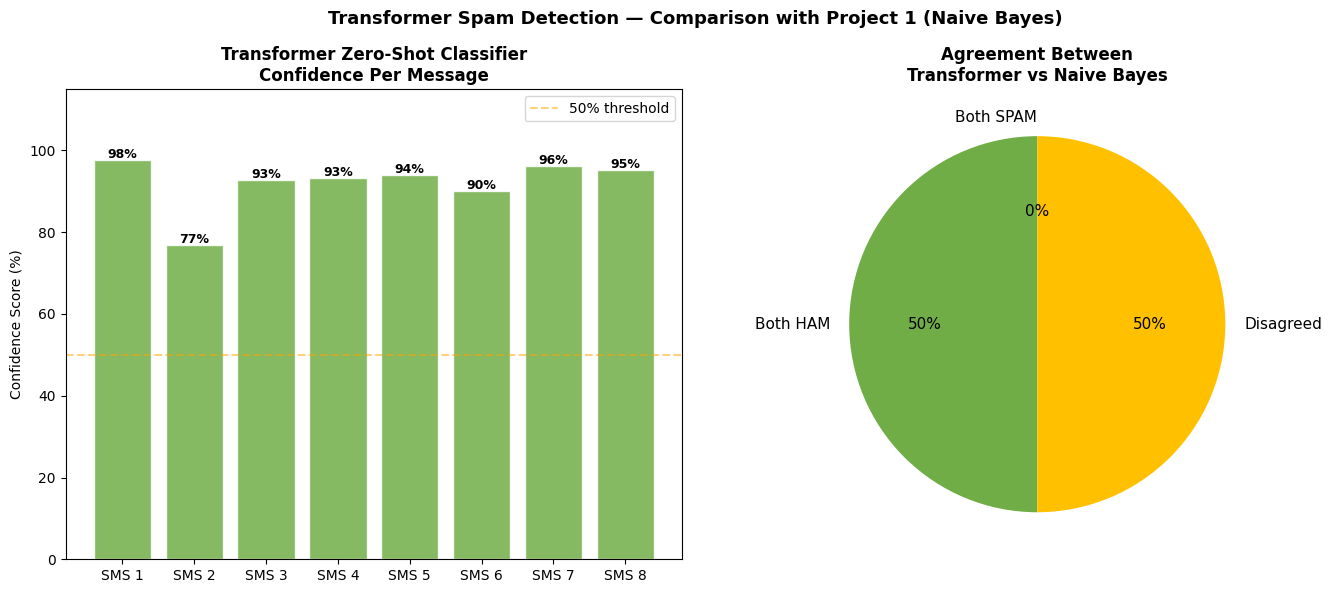


FINAL COMPARISON TABLE
Aspect                         Project 1 (TF-IDF+NB)     Week 8 (Transformer)
----------------------------------------------------------------------
  Approach                       Machine Learning          Pre-trained Transformer
  Training required              Yes (5,572 messages)      No (zero-shot)
  Accuracy (test set)            97.0%                     Depends on task framing
  Understands context            No                        Yes (attention mechanism)
  Handles new SMS                Poorly                    Well
  Speed                          Very fast                 Slower (large model)
  Computation                    Lightweight               Heavy (GPU recommended)
  Explainability                 High (feature weights)    Lower (black box)

CONCLUSION:
----------------------------------------------------------------------
  Project 1 (Naive Bayes) is faster, lighter, and achieves
  97% accuracy because it was TRAINED on spam data.

  

In [9]:
# WEEK 8 EXTRA WORK 3: Transformer Spam Detection
# Connecting Week 8 back to SMS Spam project
# Comparing TF-IDF + Naive Bayes vs Transformer approach
from transformers import pipeline
import matplotlib.pyplot as plt
import numpy as np

print("TRANSFORMER SPAM DETECTION")
print("=" * 70)
print("Upgrading our SMS Spam Classifier using Transformer zero-shot")
print("classification instead of TF-IDF + Naive Bayes\n")

# Load zero-shot classifier
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

# The same SMS messages we tested in Project 1
sms_messages = [
    "You have WON a FREE M-Pesa reward of KES 5000! Call 0712 now to claim!",
    "URGENT: Your Safaricom account will be deactivated. Verify at this link.",
    "Congratulations! You are our lucky winner. Reply CLAIM to get your prize.",
    "Hi, can you bring the textbook to class tomorrow morning?",
    "The group assignment is due on Monday. Have you done your part?",
    "Are you in Thika? Let us grab lunch after the afternoon lecture.",
    "Call me when you are free, we need to discuss the project urgently.",
    "Your account balance is low. Please top up to continue using services."
]

# What Project 1 (Naive Bayes) predicted for these same messages
project1_predictions = [
    "SPAM", "SPAM", "SPAM",
    "HAM",  "HAM",  "HAM",
    "HAM",  "SPAM"
]

labels = ["spam message", "legitimate message"]

print(f"{'#':<4} {'Message':<48} {'Transformer':<12} {'Conf':<8} {'Project1':<10} {'Match'}")
print("=" * 95)

transformer_predictions = []
confidences             = []

for i, msg in enumerate(sms_messages):
    result      = zero_shot(msg, labels)
    top_label   = result['labels'][0]
    top_score   = result['scores'][0] * 100
    prediction  = "SPAM" if "spam" in top_label else "HAM"
    proj1       = project1_predictions[i]
    match       = "✅" if prediction == proj1 else "❌"
    short_msg   = msg[:45] + "..." if len(msg) > 48 else msg

    transformer_predictions.append(prediction)
    confidences.append(top_score)

    print(f"  {i+1:<3} {short_msg:<48} {prediction:<12} {top_score:<8.1f} {proj1:<10} {match}")

# Agreement Analysis
agreed    = sum(1 for t, p in zip(transformer_predictions, project1_predictions) if t == p)
disagreed = len(sms_messages) - agreed

print(f"\nAGREEMENT ANALYSIS:")
print(f"  Both models agreed  : {agreed} out of {len(sms_messages)} messages")
print(f"  Models disagreed    : {disagreed} out of {len(sms_messages)} messages")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Confidence scores per message
colors = ['#FF4444' if p == "SPAM" else '#70AD47'
          for p in transformer_predictions]
short_labels = [f"SMS {i+1}" for i in range(len(sms_messages))]

bars = axes[0].bar(short_labels, confidences, color=colors, alpha=0.85,
                   edgecolor='white')
for bar, conf in zip(bars, confidences):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{conf:.0f}%', ha='center', fontsize=9, fontweight='bold')

axes[0].set_ylabel('Confidence Score (%)')
axes[0].set_title('Transformer Zero-Shot Classifier\nConfidence Per Message',
                  fontweight='bold')
axes[0].set_ylim(0, 115)
axes[0].axhline(y=50, color='orange', linestyle='--', alpha=0.5,
                label='50% threshold')
axes[0].legend()

# Chart 2: Comparison of predictions
categories   = ['Both SPAM', 'Both HAM', 'Disagreed']
both_spam    = sum(1 for t, p in zip(transformer_predictions, project1_predictions)
                   if t == "SPAM" and p == "SPAM")
both_ham     = sum(1 for t, p in zip(transformer_predictions, project1_predictions)
                   if t == "HAM" and p == "HAM")
disagreed_n  = disagreed

pie_values = [both_spam, both_ham, disagreed_n]
pie_colors = ['#FF4444', '#70AD47', '#FFC000']

axes[1].pie(pie_values, labels=categories, colors=pie_colors,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Agreement Between\nTransformer vs Naive Bayes',
                  fontweight='bold')

plt.suptitle('Transformer Spam Detection — Comparison with Project 1 (Naive Bayes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('transformer_spam_comparison.png', dpi=150)
plt.show()

# ---- Final Comparison Table ----
print("\nFINAL COMPARISON TABLE")
print("=" * 70)
print(f"{'Aspect':<30} {'Project 1 (TF-IDF+NB)':<25} {'Week 8 (Transformer)'}")
print("-" * 70)

comparison = [
    ("Approach",            "Machine Learning",     "Pre-trained Transformer"),
    ("Training required",   "Yes (5,572 messages)", "No (zero-shot)"),
    ("Accuracy (test set)", "97.0%",                "Depends on task framing"),
    ("Understands context", "No",                   "Yes (attention mechanism)"),
    ("Handles new SMS",     "Poorly",               "Well"),
    ("Speed",               "Very fast",            "Slower (large model)"),
    ("Computation",         "Lightweight",          "Heavy (GPU recommended)"),
    ("Explainability",      "High (feature weights)","Lower (black box)"),
]

for aspect, proj1, week8 in comparison:
    print(f"  {aspect:<30} {proj1:<25} {week8}")

print("\nCONCLUSION:")
print("-" * 70)
print("  Project 1 (Naive Bayes) is faster, lighter, and achieves")
print("  97% accuracy because it was TRAINED on spam data.")
print()
print("  The Transformer approach requires NO training data at all —")
print("  it uses zero-shot classification to detect spam purely from")
print("  understanding the meaning of the text through attention.")
print()
print("  In production, you would use a fine-tuned BERT model trained")
print("  specifically on SMS spam data — combining the best of both:")
print("  Transformer understanding + task-specific training.")
print("  This is exactly how Gmail spam detection works today.")